<a href="https://colab.research.google.com/github/xtianu/CV_Tirana_2026/blob/main/M2_Image%20Segmentation/Exercise%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 2: IMAGE SEGMENTATION

Christian Mata, PhD

# Exercise 2

**Before starting:**

- Create a GitHub repository to upload the solution of this exercise.
- Share this GitHub link to your professor.

**Objectives**

Generate a single Python notebook implementing and answering the following questions:

🔹 **Task 1:** Load an image and apply a thresholding method. Analyze and discuss the segmentation results.

🔹 **Task 2:** Load an image and apply an unsupervised segmentation method (e.g., K-Means). Evaluate and comment on the outcome.

🔹 **Task 3:** Load an image and apply a supervised segmentation method (e.g., with annotated labels or using a classifier). Discuss the effectiveness and limitations.

🔹 **Task 4:** Explain the main differences between supervised and unsupervised segmentation approaches. Discuss their advantages and disadvantages, and illustrate your explanation with an example.


**🔴 Task 1**: Threeshold Method

(2019, 1826)
uint8


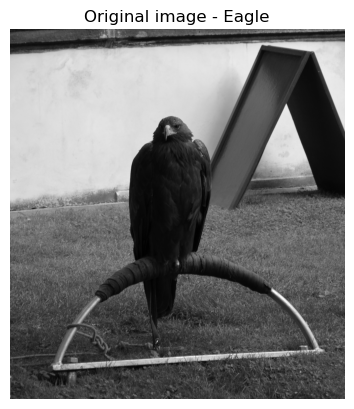

In [3]:
import skimage as sk
import matplotlib.pyplot as plt
import numpy as np

I = sk.data.eagle()

print(I.shape)
print(I.dtype)

plt.imshow(I, cmap="gray")
plt.title("Original image - Eagle")
plt.axis("off")
plt.show()



Threshold value: 139


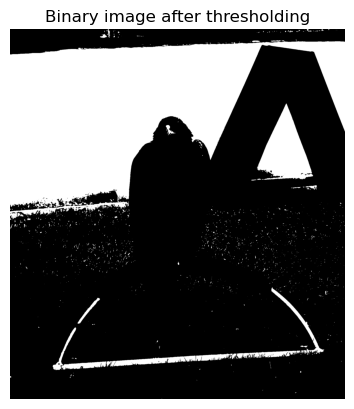

In [5]:
threshold = sk.filters.threshold_otsu(I)

print("Threshold value:", threshold)

binary = I > threshold

plt.imshow(binary, cmap="gray")
plt.title("Binary image after thresholding")
plt.axis("off")
plt.show()

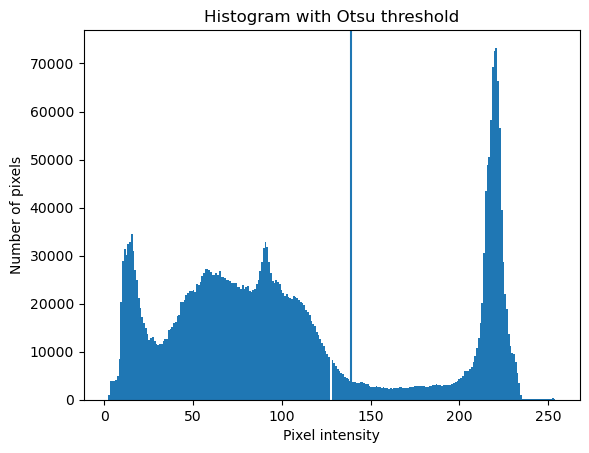

In [6]:
plt.hist(I.ravel(), bins=256)
plt.axvline(threshold)
plt.title("Histogram with Otsu threshold")
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.show()

Because the eagle is darker than most of the background, we may need to keep pixels below the threshold.

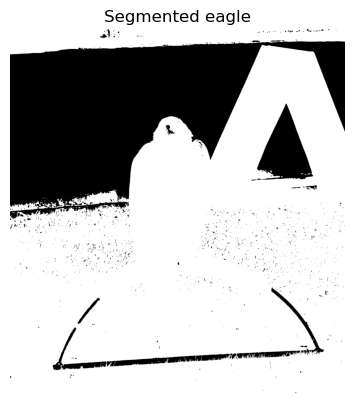

In [7]:
segmented = I < threshold

plt.imshow(segmented, cmap="gray")
plt.title("Segmented eagle")
plt.axis("off")
plt.show()

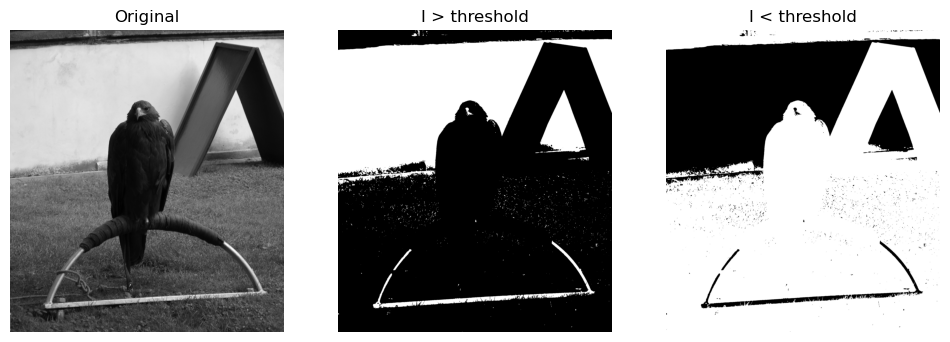

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(I, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(I > threshold, cmap="gray")
plt.title("I > threshold")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(I < threshold, cmap="gray")
plt.title("I < threshold")
plt.axis("off")

plt.show()

**Result:** The thresholding method separates the image into two classes: dark pixels and bright pixels. Since the eagle has lower intensity values than the background, using I < threshold gives the best segmentation.

However, the segmentation is not perfect. Some dark parts of the grass, perch, and background structure are also selected, because thresholding only looks at intensity values. It does not know which pixels belong to the eagle as an object.

So the result is acceptable, but it includes extra dark regions besides the eagle. This is a limitation of simple global thresholding.

**🔴 Task 2:** Unsupervised segmentation method 

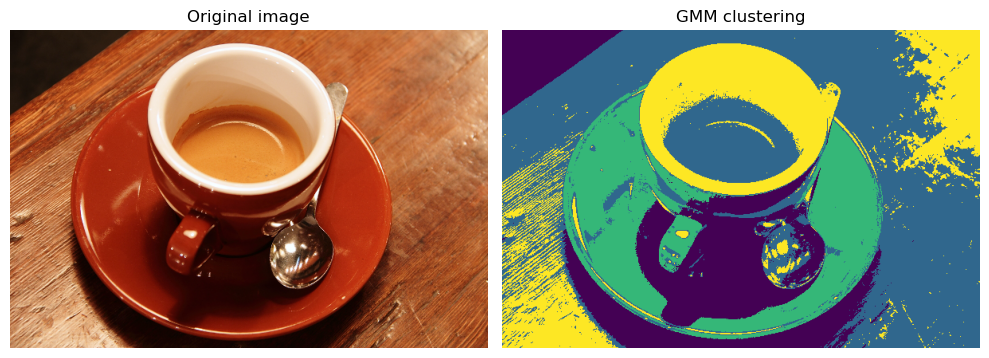

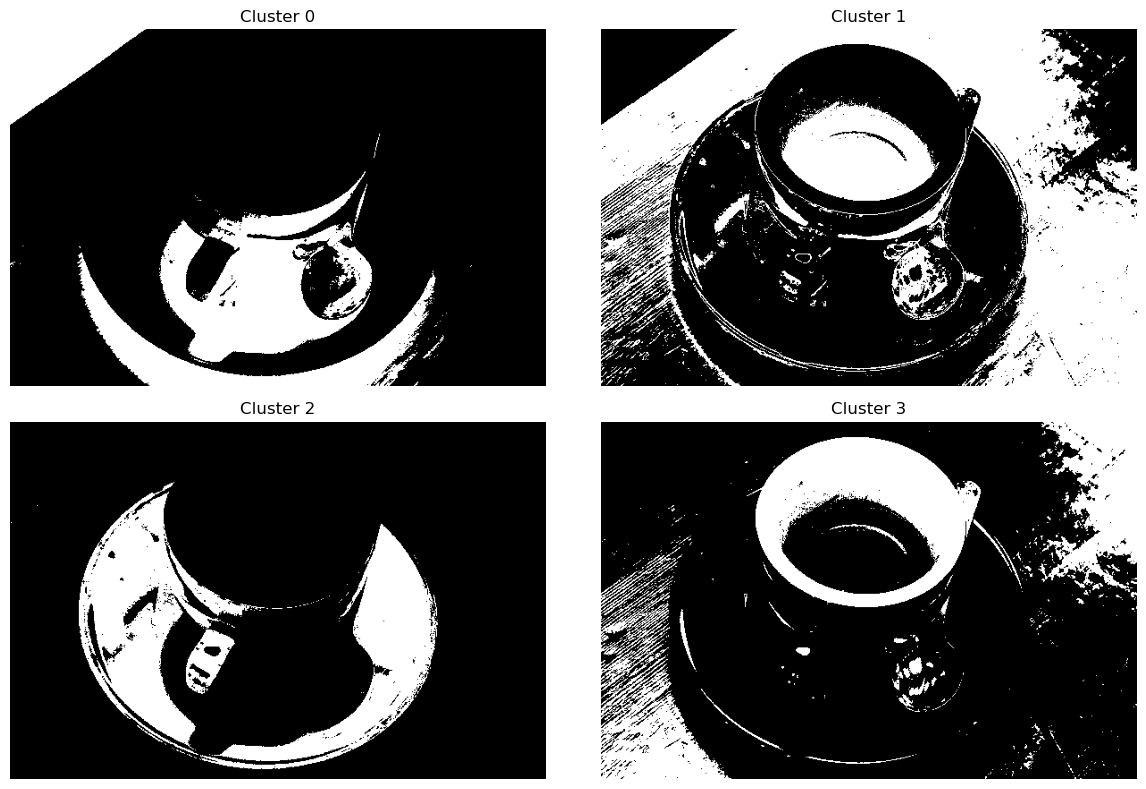

In [12]:
from matplotlib import gridspec
from sklearn import mixture

I = sk.data.coffee()
v_I = np.reshape(I, (I.shape[0] * I.shape[1], I.shape[2]))


gmm = mixture.GaussianMixture(n_components=4, random_state=0).fit(v_I)

v_gmm = gmm.fit_predict(v_I)

I_gmm = np.reshape(v_gmm, (I.shape[0], I.shape[1]))

fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(2, 2)

ax0 = fig.add_subplot(gs[0, 0])
ax0.imshow(I)
ax0.set_title('Original image')
ax0.set_axis_off()

ax1 = fig.add_subplot(gs[0, 1])
ax1.imshow(I_gmm)
ax1.set_title('GMM clustering')
ax1.set_axis_off()

plt.tight_layout()
plt.show()

# Plot individual clusters
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2)

for k in range(4):
    ax = fig.add_subplot(gs[k // 2, k % 2])
    ax.imshow(I_gmm == k, cmap="gray")
    ax.set_title("Cluster " + str(k))
    ax.set_axis_off()

plt.tight_layout()
plt.show()

**Results:** The GMM method separates the colored image into groups based on the RGB values of pixels. Since we used 4 components, the image is divided into 4 color-based clusters.

This is an unsupervised segmentation method because we did not give the algorithm any labels. The model decides the groups automatically from the pixel color distribution.

The result is better than simple thresholding for colored images because GMM uses all three RGB channels instead of only one grayscale intensity value. However, it is still not perfect because it only groups pixels by color, not by object shape. So different objects with similar colors may be placed in the same cluster.

**🔴 Task 3:** Supervised segmentation method

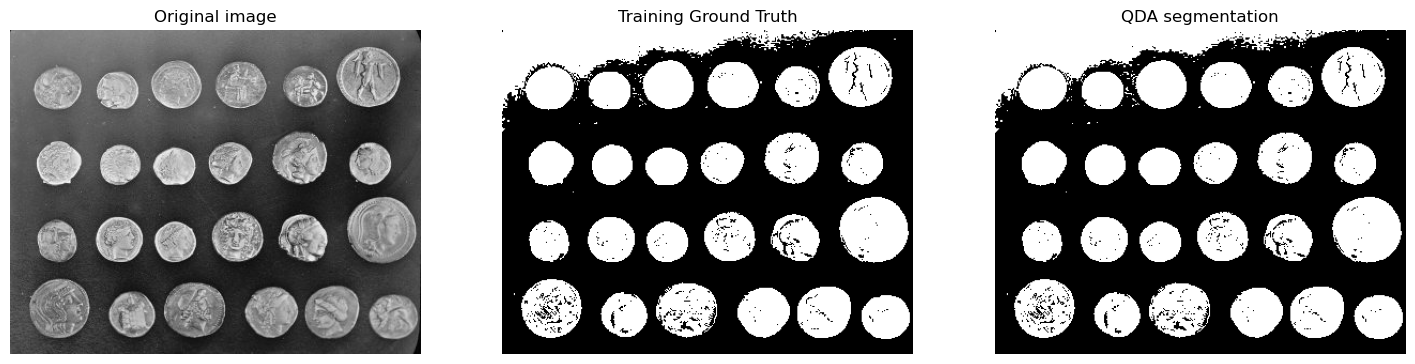

In [13]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

I = sk.data.coins()

threshold = sk.filters.threshold_otsu(I)
I_train_GT = I > threshold

v_I_train = I.reshape(I.shape[0] * I.shape[1], 1)

v_train_GT = I_train_GT.reshape(I_train_GT.shape[0] * I_train_GT.shape[1], 1).astype(np.bool_)

# Train QDA model
qda_model = QuadraticDiscriminantAnalysis(store_covariance=True)
qda_model.fit(v_I_train, v_train_GT.ravel())

# Predict segmentation
v_I_test = I.reshape(I.shape[0] * I.shape[1], 1)
v_qda = qda_model.predict(v_I_test)
I_qda = np.array(v_qda).reshape(I.shape[0], I.shape[1]).astype(np.uint8)


fig, ax = plt.subplots(1, 3, figsize=(18, 8))

ax[0].imshow(I, cmap="gray")
ax[0].set_title("Original image")
ax[0].set_axis_off()

ax[1].imshow(I_train_GT, cmap="gray")
ax[1].set_title("Training Ground Truth")
ax[1].set_axis_off()

ax[2].imshow(I_qda, cmap="gray")
ax[2].set_title("QDA segmentation")
ax[2].set_axis_off()

plt.show()

**Results:** QDA is a supervised segmentation method. It learns from labeled pixels. In this case, the labels are: 0 → background, 1 → coins.

The image is reshaped so that every pixel becomes one sample. Since this is a grayscale image, each pixel has one feature: its intensity.

QDA learns the intensity distribution of the coin pixels and the background pixels. Then it predicts whether each pixel belongs to the coin class or the background class.

The segmentation works reasonably well because coins are generally brighter than the background. However, the result is not perfect. Some background pixels may have similar intensity to coins, and some darker parts of coins may be classified as background.

The main limitation is that this QDA model only uses pixel intensity. It does not understand object shape, borders, or spatial context. So pixels are classified independently. Better results could be obtained by adding more features.

**🔴 Task 4:** Supervised vs Unsupervised Segmentation

Image segmentation means separating an image into meaningful regions.
There are two main approaches:

**Unsupervised segmentation:**
The algorithm finds groups by itself.

**Supervised segmentation:**
The algorithm learns from labeled examples.

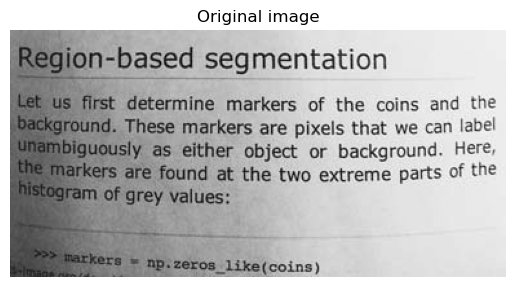

In [15]:
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix

I = sk.data.page()

plt.imshow(I, cmap=plt.cm.gray)
plt.title("Original image")
plt.axis("off")
plt.show()

v_I = I.reshape(I.shape[0] * I.shape[1], 1)


**Unsupervized segmentation: K-Means** - it does not require grouwnd truth, it only groups pixels by similarity.

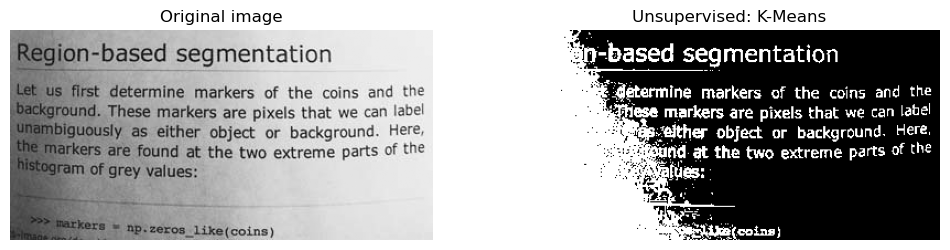

In [17]:
n_clus = 2

kmeans = KMeans(n_clusters=n_clus, random_state=0).fit(v_I)

v_kmeans = kmeans.predict(v_I)

#Since text is darker, we choose the cluster with the lowest intensity center.
text_cluster = np.argmin(kmeans.cluster_centers_)

I_kmeans = (v_kmeans == text_cluster).reshape(I.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(I, cmap=plt.cm.gray)
ax[0].set_title("Original image")
ax[0].set_axis_off()

ax[1].imshow(I_kmeans, cmap=plt.cm.gray)
ax[1].set_title("Unsupervised: K-Means")
ax[1].set_axis_off()

plt.show()

**Supervized Segmentation: QDA** is supervised, so it needs labels.  

In a real case, the ground truth would be manually annotated.
Here, we simulate a ground truth using Otsu thresholding.


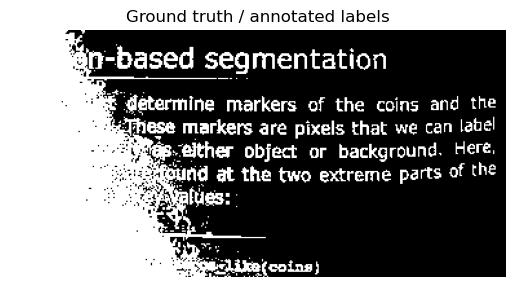

In [18]:
threshold = sk.filters.threshold_otsu(I)

#text is darker than the background.
I_GT = I < threshold

plt.imshow(I_GT, cmap=plt.cm.gray)
plt.title("Ground truth / annotated labels")
plt.axis("off")
plt.show()

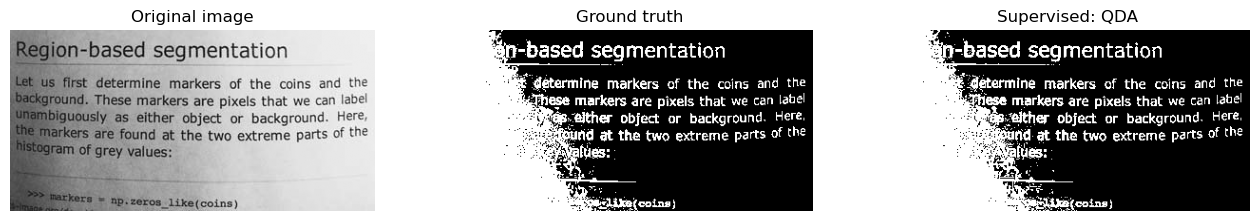

In [20]:

v_train_GT = I_GT.reshape(I_GT.shape[0] * I_GT.shape[1], 1).astype(np.bool_)

qda_model = QuadraticDiscriminantAnalysis(store_covariance=True)

qda_model.fit(v_I, v_train_GT.ravel())

v_qda = qda_model.predict(v_I)

I_qda = np.array(v_qda).reshape(I.shape[0], I.shape[1]).astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(16, 6))

ax[0].imshow(I, cmap=plt.cm.gray)
ax[0].set_title("Original image")
ax[0].set_axis_off()

ax[1].imshow(I_GT, cmap=plt.cm.gray)
ax[1].set_title("Ground truth")
ax[1].set_axis_off()

ax[2].imshow(I_qda, cmap=plt.cm.gray)
ax[2].set_title("Supervised: QDA")
ax[2].set_axis_off()

plt.show()

In [21]:
CM_qda = confusion_matrix(v_train_GT, np.array(v_qda).astype(np.bool_))

tn, fp, fn, tp = CM_qda.ravel()

TPR_qda = tp / (tp + fn)
FPR_qda = fp / (fp + tn)
DSC_qda = 2 * tp / (2 * tp + fp + fn)

print("QDA Segmentation:")
print("TPR =", TPR_qda)
print("FPR =", FPR_qda)
print("DSC =", DSC_qda)

QDA Segmentation:
TPR = 1.0
FPR = 0.015877390087760207
DSC = 0.9858916159656426


## Comparison between Supervised and Unsupervised Segmentation

| Feature | Unsupervised Segmentation | Supervised Segmentation |
|---|---|---|
| Main idea | The algorithm finds groups automatically from the image data. | The algorithm learns from labeled examples or ground truth masks. |
| Labels required? | No labels are needed. | Labels / ground truth are required. |
| Example method used | K-Means clustering | Quadratic Discriminant Analysis (QDA) |
| Input used | Pixel intensity values only | Pixel intensity values + foreground/background labels |
| Output | Clusters of similar pixels | Predicted classes, such as foreground and background |
| Advantage | Simple, fast, and useful when no annotated data is available. | More controlled and usually more accurate when good labels are available. |
| Disadvantage | It does not know the real meaning of the object; it only groups similar pixels. | It depends on the quality of the labeled ground truth. |
| Result in this task | Produced a good segmentation because the foreground and background were clearly different. | Produced an almost identical segmentation because the image was already easy to separate. |
| Best used when | There is no labeled data and the image has clear intensity/color differences. | There is labeled data and the segmentation problem is more complex. |
| Main limitation | Similar-looking regions may be grouped together even if they are different objects. | Creating training labels can be time-consuming. |